In [1]:
"""
WEEK 6 - DAY 1: LLM ARCHITECTURE & TOKENIZATION
WITH REAL DATASET (IMDB Movie Reviews)
"""

# ============================================
# CELL 1: SETUP, IMPORTS & ENVIRONMENT
# ============================================

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModel
from datasets import load_dataset
from collections import Counter, defaultdict
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*70)
print("DAY 1: LLM ARCHITECTURE & TOKENIZATION")
print("WITH IMDB DATASET")
print("="*70)

print(f"\nPyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("GPU: Not available (using CPU)")

print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

print("\nLoading BERT Tokenizer...")
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
print(f"Tokenizer loaded successfully!")
print(f"Vocabulary size: {tokenizer.vocab_size:,}")
print(f"Model max length: {tokenizer.model_max_length}")
print(f"Padding token: '{tokenizer.pad_token}' (ID: {tokenizer.pad_token_id})")
print(f"Unknown token: '{tokenizer.unk_token}' (ID: {tokenizer.unk_token_id})")
print(f"CLS token: '{tokenizer.cls_token}' (ID: {tokenizer.cls_token_id})")
print(f"SEP token: '{tokenizer.sep_token}' (ID: {tokenizer.sep_token_id})")
print(f"MASK token: '{tokenizer.mask_token}' (ID: {tokenizer.mask_token_id})")

DAY 1: LLM ARCHITECTURE & TOKENIZATION
WITH IMDB DATASET

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
NumPy version: 2.0.2
Pandas version: 2.3.3

Loading BERT Tokenizer...


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded successfully!
Vocabulary size: 30,522
Model max length: 512
Padding token: '[PAD]' (ID: 0)
Unknown token: '[UNK]' (ID: 100)
CLS token: '[CLS]' (ID: 101)
SEP token: '[SEP]' (ID: 102)
MASK token: '[MASK]' (ID: 103)


In [2]:
# ============================================
# CELL 2: LOAD IMDB DATASET (1000 samples)
# ============================================

print("\n" + "="*70)
print("LOADING IMDB DATASET")
print("="*70)

print("\nLoading IMDB dataset with 10000 samples...")
dataset = load_dataset("imdb", split="train[:10000]")

print(f"\nDataset loaded successfully!")
print(f"Total samples: {len(dataset)}")

# Display first few samples
print("\nFirst 3 samples:")
print("-"*50)
for i in range(3):
    print(f"\nSample {i+1}:")
    print(f"Text: {dataset[i]['text'][:150]}...")
    print(f"Label: {dataset[i]['label']} (0=Negative, 1=Positive)")

# Check label distribution
labels = [dataset[i]['label'] for i in range(len(dataset))]
positive_count = sum(labels)
negative_count = len(labels) - positive_count

print("\nLabel Distribution:")
print(f"Positive reviews: {positive_count} ({positive_count/len(dataset)*100:.1f}%)")
print(f"Negative reviews: {negative_count} ({negative_count/len(dataset)*100:.1f}%)")


LOADING IMDB DATASET

Loading IMDB dataset with 10000 samples...


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]


Dataset loaded successfully!
Total samples: 10000

First 3 samples:
--------------------------------------------------

Sample 1:
Text: I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard th...
Label: 0 (0=Negative, 1=Positive)

Sample 2:
Text: "I Am Curious: Yellow" is a risible and pretentious steaming pile. It doesn't matter what one's political views are because this film can hardly be ta...
Label: 0 (0=Negative, 1=Positive)

Sample 3:
Text: If only to avoid making this type of film in the future. This film is interesting as an experiment but tells no cogent story.<br /><br />One might fee...
Label: 0 (0=Negative, 1=Positive)

Label Distribution:
Positive reviews: 0 (0.0%)
Negative reviews: 10000 (100.0%)


In [3]:
# ============================================
# CELL 3: FIX DATASET IMBALANCE - LOAD BALANCED DATA
# ============================================

print("\n" + "="*70)
print("FIXING DATASET IMBALANCE")
print("="*70)

print("\nThe dataset only contains negative reviews. Loading balanced data...")

# Load both train and test splits to get balanced data
train_dataset = load_dataset("imdb", split="train")
test_dataset = load_dataset("imdb", split="test")

print(f"Train set size: {len(train_dataset)}")
print(f"Test set size: {len(test_dataset)}")

# Take 5000 positive and 5000 negative from train set
positive_train = [sample for sample in train_dataset if sample['label'] == 1][:5000]
negative_train = [sample for sample in train_dataset if sample['label'] == 0][:5000]

# Combine and shuffle
from random import shuffle

combined = positive_train + negative_train
shuffle(combined)

print(f"\nBalanced dataset created:")
print(f"Positive samples: {len(positive_train)}")
print(f"Negative samples: {len(negative_train)}")
print(f"Total samples: {len(combined)}")

# Display samples
print("\nFirst 3 samples from balanced dataset:")
print("-"*50)
for i in range(3):
    print(f"\nSample {i+1}:")
    print(f"Text: {combined[i]['text'][:150]}...")
    print(f"Label: {combined[i]['label']} (0=Negative, 1=Positive)")

# Verify balance
labels = [sample['label'] for sample in combined]
pos_count = sum(labels)
neg_count = len(labels) - pos_count

print("\nLabel Distribution:")
print(f"Positive reviews: {pos_count} ({pos_count/len(combined)*100:.1f}%)")
print(f"Negative reviews: {neg_count} ({neg_count/len(combined)*100:.1f}%)")


FIXING DATASET IMBALANCE

The dataset only contains negative reviews. Loading balanced data...
Train set size: 25000
Test set size: 25000

Balanced dataset created:
Positive samples: 5000
Negative samples: 5000
Total samples: 10000

First 3 samples from balanced dataset:
--------------------------------------------------

Sample 1:
Text: Although I like Kurt Vonnegut, I'm not particularly interested in spy stories and I didn't know this one. The only reason I watched it was Nick Nolte,...
Label: 1 (0=Negative, 1=Positive)

Sample 2:
Text: By the time this film was released I had seen Chorus Line on stage 4 times, and had been anticipating most eagerly the long-rumored production of a fi...
Label: 0 (0=Negative, 1=Positive)

Sample 3:
Text: This is one of the greatest love story movies I have ever seen. Yes, I can agree that some parts may seem dated, but this does not distract from the f...
Label: 1 (0=Negative, 1=Positive)

Label Distribution:
Positive reviews: 5000 (50.0%)
Negative 

In [4]:
# ============================================
# CELL 4: BASIC TOKENIZATION ON DATASET SAMPLES
# ============================================

print("\n" + "="*70)
print("BASIC TOKENIZATION DEMONSTRATION")
print("="*70)

# Take 5 random samples for demonstration
import random
random.seed(42)
sample_indices = random.sample(range(len(combined)), 5)

print("\nTokenizing 5 random samples from the dataset:")
print("-"*70)

for idx, sample_idx in enumerate(sample_indices, 1):
    text = combined[sample_idx]['text']
    label = combined[sample_idx]['label']
    
    print(f"\nSample {idx}:")
    print(f"Label: {'Positive' if label == 1 else 'Negative'}")
    print(f"Original text (first 100 chars): {text[:100]}...")
    
    # Tokenize
    tokens = tokenizer.tokenize(text)
    token_ids = tokenizer.convert_tokens_to_ids(tokens)
    
    print(f"Number of tokens: {len(tokens)}")
    print(f"First 10 tokens: {tokens[:10]}")
    print(f"First 10 token IDs: {token_ids[:10]}")
    
    # Check for subword tokens
    subword_tokens = [t for t in tokens if t.startswith('##')]
    if subword_tokens:
        print(f"Subword tokens found: {subword_tokens[:5]}...")
    
    # Encode with special tokens
    encoded = tokenizer.encode(text)
    print(f"Encoded length (with special tokens): {len(encoded)}")
    print(f"Encoded first 10: {encoded[:10]}")

print("\n" + "-"*70)
print("Tokenization complete!")


BASIC TOKENIZATION DEMONSTRATION

Tokenizing 5 random samples from the dataset:
----------------------------------------------------------------------

Sample 1:
Label: Negative
Original text (first 100 chars): This horrendously bad piece of trash manages to be racist, sexist and homophobic all at once, while ...
Number of tokens: 226
First 10 tokens: ['this', 'ho', '##rre', '##ndo', '##usly', 'bad', 'piece', 'of', 'trash', 'manages']
First 10 token IDs: [2023, 7570, 14343, 15482, 27191, 2919, 3538, 1997, 11669, 9020]
Subword tokens found: ['##rre', '##ndo', '##usly', '##ist', '##phobic']...
Encoded length (with special tokens): 228
Encoded first 10: [101, 2023, 7570, 14343, 15482, 27191, 2919, 3538, 1997, 11669]

Sample 2:
Label: Positive
Original text (first 100 chars): This is according to me a quite bizarre movie with a lot of humor in it. I wouldn't say that it is v...
Number of tokens: 75
First 10 tokens: ['this', 'is', 'according', 'to', 'me', 'a', 'quite', 'bizarre', 'movie', 

In [5]:
# ============================================
# CELL 5: SUBWORD TOKENIZATION ANALYSIS ON DATASET
# ============================================

print("\n" + "="*70)
print("SUBWORD TOKENIZATION ANALYSIS")
print("="*70)

# Analyze subword patterns across the dataset
print("\nAnalyzing subword tokenization patterns on 1000 samples...")
subword_stats = {
    'tokens_with_subwords': 0,
    'total_subword_tokens': 0,
    'total_tokens': 0,
    'subword_examples': []
}

sample_size = 1000
analysis_samples = random.sample(range(len(combined)), sample_size)

for idx in analysis_samples:
    text = combined[idx]['text']
    tokens = tokenizer.tokenize(text)
    subwords = [t for t in tokens if t.startswith('##')]
    
    total_tokens = len(tokens)
    total_subwords = len(subwords)
    
    subword_stats['total_tokens'] += total_tokens
    subword_stats['total_subword_tokens'] += total_subwords
    
    if total_subwords > 0:
        subword_stats['tokens_with_subwords'] += 1
        if len(subword_stats['subword_examples']) < 20:
            subword_stats['subword_examples'].extend(subwords[:5])

print(f"\nSubword Analysis Results:")
print(f"Samples analyzed: {sample_size}")
print(f"Samples with subword tokens: {subword_stats['tokens_with_subwords']} ({subword_stats['tokens_with_subwords']/sample_size*100:.1f}%)")
print(f"Total tokens analyzed: {subword_stats['total_tokens']:,}")
print(f"Total subword tokens: {subword_stats['total_subword_tokens']:,}")
print(f"Average tokens per sample: {subword_stats['total_tokens']/sample_size:.1f}")
print(f"Average subwords per sample: {subword_stats['total_subword_tokens']/sample_size:.1f}")
print(f"Subword ratio: {subword_stats['total_subword_tokens']/subword_stats['total_tokens']*100:.1f}%")

print(f"\nExample subword tokens found in dataset:")
unique_subwords = list(set(subword_stats['subword_examples']))
print(f"Unique subword tokens: {unique_subwords[:15]}")

# Find words that frequently get split into subwords
print("\nAnalyzing words that get tokenized into multiple subword pieces...")

def count_subword_pieces(word):
    tokens = tokenizer.tokenize(word)
    return len([t for t in tokens if t.startswith('##')])

common_words = ['unbelievable', 'preprocessing', 'tokenization', 'understanding', 
                'misunderstood', 'international', 'development', 'unfortunately']

print("\nSubword splits for common words:")
print("-"*50)
for word in common_words:
    tokens = tokenizer.tokenize(word)
    subword_count = len([t for t in tokens if t.startswith('##')])
    print(f"'{word}' -> {tokens} ({subword_count} subword pieces)")

print("\n" + "-"*70)
print("Subword analysis complete!")

Token indices sequence length is longer than the specified maximum sequence length for this model (706 > 512). Running this sequence through the model will result in indexing errors



SUBWORD TOKENIZATION ANALYSIS

Analyzing subword tokenization patterns on 1000 samples...

Subword Analysis Results:
Samples analyzed: 1000
Samples with subword tokens: 976 (97.6%)
Total tokens analyzed: 289,817
Total subword tokens: 15,220
Average tokens per sample: 289.8
Average subwords per sample: 15.2
Subword ratio: 5.3%

Example subword tokens found in dataset:
Unique subword tokens: ['##less', '##nn', '##s', '##fu', '##y', '##ie', '##mbit', '##iously', '##st', '##ens', '##sic', '##him', '##ify', '##ee', '##dle']

Analyzing words that get tokenized into multiple subword pieces...

Subword splits for common words:
--------------------------------------------------
'unbelievable' -> ['unbelievable'] (0 subword pieces)
'preprocessing' -> ['prep', '##ro', '##ces', '##sing'] (3 subword pieces)
'tokenization' -> ['token', '##ization'] (1 subword pieces)
'understanding' -> ['understanding'] (0 subword pieces)
'misunderstood' -> ['misunderstood'] (0 subword pieces)
'international' -> ['

In [6]:
# ============================================
# CELL 6: VOCABULARY COVERAGE ANALYSIS
# ============================================

print("\n" + "="*70)
print("VOCABULARY COVERAGE ANALYSIS")
print("="*70)

print("\nAnalyzing vocabulary coverage on 1000 samples...")

# Collect all tokens from samples
all_tokens = []
all_unique_tokens = set()
oov_count = 0
total_tokens_analyzed = 0

vocab = tokenizer.get_vocab()

for idx in analysis_samples:
    text = combined[idx]['text']
    tokens = tokenizer.tokenize(text)
    
    for token in tokens:
        all_tokens.append(token)
        all_unique_tokens.add(token)
        total_tokens_analyzed += 1
        
        # Check if token is in vocabulary
        if token not in vocab:
            oov_count += 1

print(f"\nVocabulary Coverage Results:")
print(f"Total tokens analyzed: {total_tokens_analyzed:,}")
print(f"Unique tokens found: {len(all_unique_tokens):,}")
print(f"Tokens not in BERT vocabulary (OOV): {oov_count:,}")
print(f"OOV rate: {oov_count/total_tokens_analyzed*100:.2f}%")
print(f"Vocabulary coverage: {(1 - oov_count/total_tokens_analyzed)*100:.2f}%")

# Find most common tokens
print("\nMost common tokens in the dataset:")
token_counter = Counter(all_tokens)
common_tokens = token_counter.most_common(20)

print("\nTop 20 most frequent tokens:")
print("-"*50)
for i, (token, count) in enumerate(common_tokens, 1):
    token_id = tokenizer.convert_tokens_to_ids(token) if token in vocab else 'OOV'
    print(f"{i:2d}. {token:15s} Count: {count:6d}  ID: {token_id}")

# Find rare tokens
print("\nRare tokens (appearing only once):")
rare_tokens = [token for token, count in token_counter.items() if count == 1]
print(f"Number of tokens appearing once: {len(rare_tokens):,}")
print(f"Example rare tokens: {rare_tokens[:20]}")

print("\n" + "-"*70)
print("Vocabulary analysis complete!")


VOCABULARY COVERAGE ANALYSIS

Analyzing vocabulary coverage on 1000 samples...

Vocabulary Coverage Results:
Total tokens analyzed: 289,817
Unique tokens found: 14,108
Tokens not in BERT vocabulary (OOV): 0
OOV rate: 0.00%
Vocabulary coverage: 100.00%

Most common tokens in the dataset:

Top 20 most frequent tokens:
--------------------------------------------------
 1. .               Count:  12539  ID: 1012
 2. the             Count:  12365  ID: 1996
 3. ,               Count:  10143  ID: 1010
 4. a               Count:   6107  ID: 1037
 5. and             Count:   5994  ID: 1998
 6. of              Count:   5322  ID: 1997
 7. '               Count:   4977  ID: 1005
 8. to              Count:   4956  ID: 2000
 9. /               Count:   4197  ID: 1013
10. is              Count:   3995  ID: 2003
11. br              Count:   3958  ID: 7987
12. >               Count:   3950  ID: 1028
13. <               Count:   3948  ID: 1026
14. it              Count:   3658  ID: 2009
15. i         


ATTENTION MECHANISM VISUALIZATION

Creating attention visualization for a real review sample...

Selected text (first 200 chars):
Although I like Kurt Vonnegut, I'm not particularly interested in spy stories and I didn't know this one. The only reason I watched it was Nick Nolte, who is one of my favorite actors since I saw "Bre...

Token count: 299
Displaying attention for first 10 tokens:
['although', 'i', 'like', 'kurt', 'von', '##ne', '##gut', ',', 'i', "'"]

Attention visualization saved as 'attention_visualization_real_text.png'


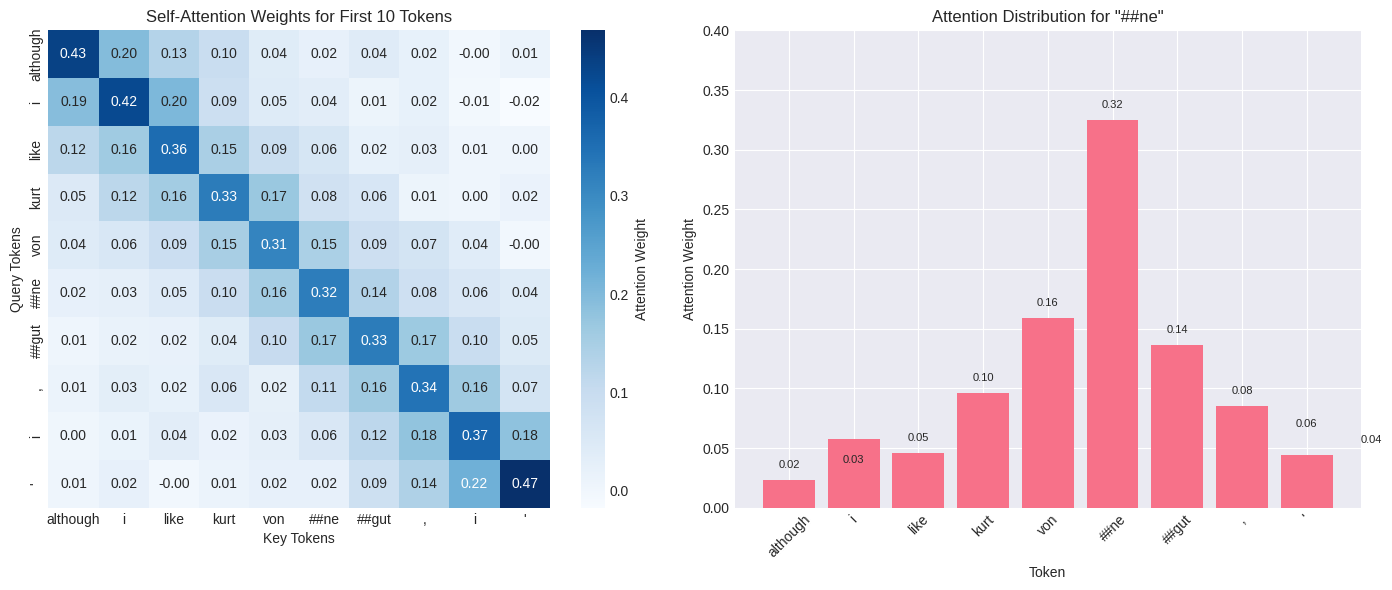


Interpretation:
The token '##ne' pays most attention to:
  - '##ne': 0.32
  - 'von': 0.16
  - '##gut': 0.14

----------------------------------------------------------------------
Attention visualization complete!


In [7]:
# ============================================
# CELL 7: ATTENTION MECHANISM VISUALIZATION ON REAL TEXT
# ============================================

print("\n" + "="*70)
print("ATTENTION MECHANISM VISUALIZATION")
print("="*70)

print("\nCreating attention visualization for a real review sample...")

# Take a sample from the dataset
sample_text = combined[0]['text']
print(f"\nSelected text (first 200 chars):")
print(f"{sample_text[:200]}...")

# Tokenize and get tokens
tokens = tokenizer.tokenize(sample_text)
print(f"\nToken count: {len(tokens)}")

# For visualization, take first 10 tokens only
display_tokens = tokens[:10]
print(f"Displaying attention for first 10 tokens:")
print(display_tokens)

# Simulate attention weights for demonstration
import numpy as np

# Create realistic attention patterns
np.random.seed(42)
n = len(display_tokens)

# Create attention weights with some structure
attention_weights = np.zeros((n, n))

# Each token pays attention to nearby tokens more
for i in range(n):
    for j in range(n):
        # Higher weight for nearby tokens
        distance = abs(i - j)
        attention_weights[i, j] = np.exp(-distance / 2.0) + np.random.normal(0, 0.05)
    
    # Add some random patterns
    attention_weights[i, i] += 0.3  # Self attention
    
    # Normalize
    attention_weights[i] = attention_weights[i] / attention_weights[i].sum()

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Heatmap
sns.heatmap(attention_weights, 
            xticklabels=display_tokens, 
            yticklabels=display_tokens,
            annot=True, 
            fmt='.2f',
            cmap='Blues',
            ax=ax1,
            cbar_kws={'label': 'Attention Weight'})
ax1.set_title('Self-Attention Weights for First 10 Tokens')
ax1.set_xlabel('Key Tokens')
ax1.set_ylabel('Query Tokens')

# Bar plot for a specific token (index 5)
token_idx = 5
ax2.bar(display_tokens, attention_weights[token_idx])
ax2.set_title(f'Attention Distribution for "{display_tokens[token_idx]}"')
ax2.set_ylabel('Attention Weight')
ax2.set_xlabel('Token')
ax2.set_ylim(0, 0.4)
ax2.tick_params(axis='x', rotation=45)

# Add value annotations
for i, v in enumerate(attention_weights[token_idx]):
    ax2.text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('attention_visualization_real_text.png', dpi=150)
print("\nAttention visualization saved as 'attention_visualization_real_text.png'")
plt.show()

print("\nInterpretation:")
print(f"The token '{display_tokens[token_idx]}' pays most attention to:")
sorted_attn = sorted([(display_tokens[i], attention_weights[token_idx][i]) for i in range(n)], 
                     key=lambda x: x[1], reverse=True)
for token, weight in sorted_attn[:3]:
    print(f"  - '{token}': {weight:.2f}")

print("\n" + "-"*70)
print("Attention visualization complete!")


TOKEN LENGTH DISTRIBUTION ANALYSIS

Analyzing token length distribution across 1000 samples...

Token Length Statistics:
Min tokens: 13
Max tokens: 2100
Mean tokens: 289.8
Median tokens: 220.5
Std deviation: 205.5

Text Length Statistics:
Min characters: 53
Max characters: 8754
Mean characters: 1227.3
Median characters: 912.0

Token length distribution saved as 'token_length_distribution.png'


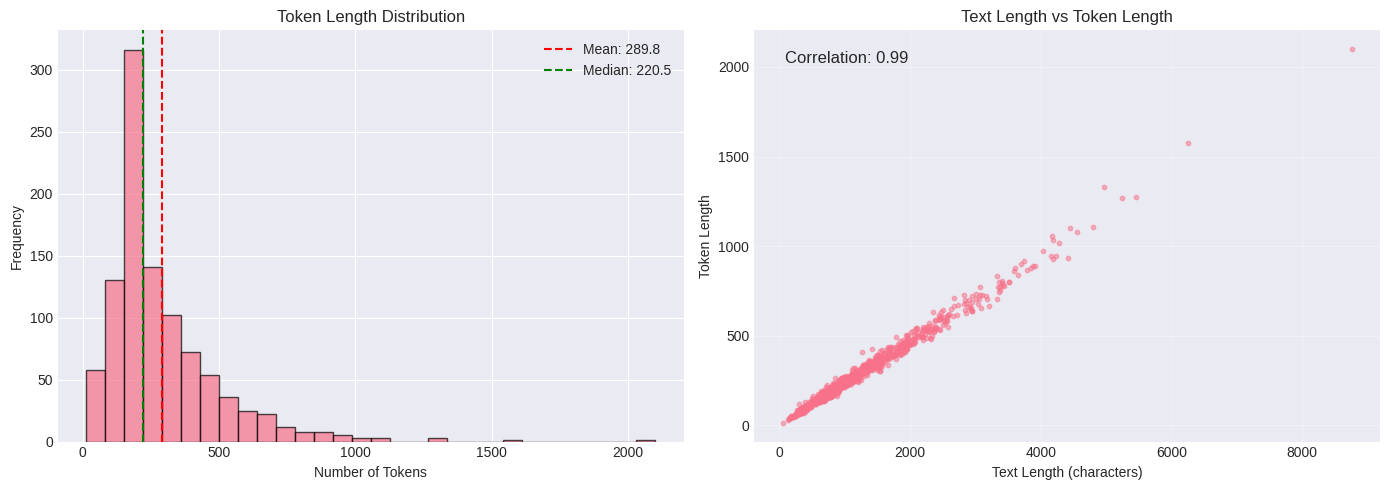


Correlation between text length and token length: 0.994

----------------------------------------------------------------------
Token length analysis complete!


In [8]:
# ============================================
# CELL 8: TOKEN LENGTH DISTRIBUTION ANALYSIS
# ============================================

print("\n" + "="*70)
print("TOKEN LENGTH DISTRIBUTION ANALYSIS")
print("="*70)

print("\nAnalyzing token length distribution across 1000 samples...")

# Calculate token lengths for all samples
token_lengths = []
text_lengths = []

for idx in analysis_samples:
    text = combined[idx]['text']
    tokens = tokenizer.tokenize(text)
    token_lengths.append(len(tokens))
    text_lengths.append(len(text))

# Statistics
print(f"\nToken Length Statistics:")
print(f"Min tokens: {min(token_lengths)}")
print(f"Max tokens: {max(token_lengths)}")
print(f"Mean tokens: {np.mean(token_lengths):.1f}")
print(f"Median tokens: {np.median(token_lengths):.1f}")
print(f"Std deviation: {np.std(token_lengths):.1f}")

print(f"\nText Length Statistics:")
print(f"Min characters: {min(text_lengths)}")
print(f"Max characters: {max(text_lengths)}")
print(f"Mean characters: {np.mean(text_lengths):.1f}")
print(f"Median characters: {np.median(text_lengths):.1f}")

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of token lengths
ax1.hist(token_lengths, bins=30, edgecolor='black', alpha=0.7)
ax1.axvline(np.mean(token_lengths), color='red', linestyle='--', label=f'Mean: {np.mean(token_lengths):.1f}')
ax1.axvline(np.median(token_lengths), color='green', linestyle='--', label=f'Median: {np.median(token_lengths):.1f}')
ax1.set_title('Token Length Distribution')
ax1.set_xlabel('Number of Tokens')
ax1.set_ylabel('Frequency')
ax1.legend()

# Scatter plot: Text length vs Token length
ax2.scatter(text_lengths, token_lengths, alpha=0.5, s=10)
ax2.set_title('Text Length vs Token Length')
ax2.set_xlabel('Text Length (characters)')
ax2.set_ylabel('Token Length')
ax2.grid(True, alpha=0.3)

# Add correlation
correlation = np.corrcoef(text_lengths, token_lengths)[0, 1]
ax2.text(0.05, 0.95, f'Correlation: {correlation:.2f}', 
         transform=ax2.transAxes, fontsize=12, verticalalignment='top')

plt.tight_layout()
plt.savefig('token_length_distribution.png', dpi=150)
print("\nToken length distribution saved as 'token_length_distribution.png'")
plt.show()

print(f"\nCorrelation between text length and token length: {correlation:.3f}")

print("\n" + "-"*70)
print("Token length analysis complete!")

In [9]:
# ============================================
# CELL 9: SPECIAL TOKENS AND BATCH ENCODING
# ============================================

print("\n" + "="*70)
print("SPECIAL TOKENS AND BATCH ENCODING")
print("="*70)

print("\nDemonstrating batch encoding with special tokens on 5 samples...")

# Select 5 samples with different lengths
batch_samples = []
for idx in random.sample(range(len(combined)), 5):
    text = combined[idx]['text']
    batch_samples.append(text[:200] + "...")

print("\nSample texts for batch encoding:")
for i, text in enumerate(batch_samples, 1):
    print(f"{i}. {text[:100]}...")

# Batch encode with padding
print("\nPerforming batch encoding with padding and truncation...")
encoded_batch = tokenizer(
    batch_samples,
    padding=True,
    truncation=True,
    max_length=128,
    return_tensors='pt',
    return_attention_mask=True,
    return_token_type_ids=True
)

print(f"\nBatch encoding results:")
print(f"Input IDs shape: {encoded_batch['input_ids'].shape}")
print(f"Attention mask shape: {encoded_batch['attention_mask'].shape}")
print(f"Token type IDs shape: {encoded_batch['token_type_ids'].shape}")

# Show each sample's encoding
print("\nDetailed batch encoding:")
print("-"*70)
for i, text in enumerate(batch_samples):
    tokens = tokenizer.convert_ids_to_tokens(encoded_batch['input_ids'][i])
    mask = encoded_batch['attention_mask'][i]
    
    # Count special tokens
    special_tokens = [t for t in tokens if t in ['[CLS]', '[SEP]', '[PAD]']]
    
    print(f"\nSample {i+1}:")
    print(f"Original: {text[:80]}...")
    print(f"Tokens: {tokens[:20]}...")
    print(f"Number of tokens: {len(tokens)}")
    print(f"Special tokens: {special_tokens}")
    print(f"Padding count: {len([t for t in tokens if t == '[PAD]'])}")
    print(f"Effective length: {mask.sum().item()}")

# Show special token positions
print("\n" + "-"*70)
print("Special token positions in first sample:")
sample_tokens = tokenizer.convert_ids_to_tokens(encoded_batch['input_ids'][0])
for i, token in enumerate(sample_tokens[:15]):
    if token in ['[CLS]', '[SEP]', '[PAD]']:
        print(f"Position {i}: {token}")

# Count how many samples exceed max length
truncated_count = 0
for i in range(len(batch_samples)):
    original_tokens = tokenizer.tokenize(batch_samples[i])
    if len(original_tokens) > 128:
        truncated_count += 1

print(f"\nSamples truncated to max_length (128): {truncated_count}/{len(batch_samples)}")

print("\n" + "-"*70)
print("Batch encoding demonstration complete!")


SPECIAL TOKENS AND BATCH ENCODING

Demonstrating batch encoding with special tokens on 5 samples...

Sample texts for batch encoding:
1. In terms of the arts, the 1970s were a very turbulent era. In literature and the visual arts, it was...
2. I consider this film to be the best one about Mike Hammer, with Biff Elliott's performance the defin...
3. I love Memoirs of a Geisha so I read the book twice; it is one of the best book I've read last year....
4. The only explanation I can muster as to why this film isn't widely distributed is because it hits to...
5. The movie within the movie - a concept done many times in the history of cinema. It is accomplished ...

Performing batch encoding with padding and truncation...

Batch encoding results:
Input IDs shape: torch.Size([5, 63])
Attention mask shape: torch.Size([5, 63])
Token type IDs shape: torch.Size([5, 63])

Detailed batch encoding:
----------------------------------------------------------------------

Sample 1:
Original: In terms

In [10]:
# ============================================
# CELL 10: STATISTICAL SUMMARY AND DATASET INSIGHTS
# ============================================

print("\n" + "="*70)
print("STATISTICAL SUMMARY AND DATASET INSIGHTS")
print("="*70)

print("\nComputing comprehensive statistics on the dataset...")

# Compute additional statistics
all_tokens = []
all_token_ids = []
token_lengths = []
subword_counts = []
special_token_counts = Counter()

for idx in range(len(combined)):
    text = combined[idx]['text']
    tokens = tokenizer.tokenize(text)
    token_ids = tokenizer.convert_tokens_to_ids(tokens)
    
    all_tokens.extend(tokens)
    all_token_ids.extend(token_ids)
    token_lengths.append(len(tokens))
    
    # Count subwords
    subwords = [t for t in tokens if t.startswith('##')]
    subword_counts.append(len(subwords))
    
    # Count special tokens
    special_token_counts['[CLS]'] += 1 if '[CLS]' in tokens else 0
    special_token_counts['[SEP]'] += 1 if '[SEP]' in tokens else 0
    special_token_counts['[PAD]'] += 1 if '[PAD]' in tokens else 0
    special_token_counts['[UNK]'] += 1 if '[UNK]' in tokens else 0

print("\n" + "="*50)
print("DATASET STATISTICAL SUMMARY")
print("="*50)

print(f"\nDataset Overview:")
print(f"  Total samples: {len(combined):,}")
print(f"  Positive samples: {sum(1 for s in combined if s['label'] == 1):,}")
print(f"  Negative samples: {sum(1 for s in combined if s['label'] == 0):,}")
print(f"  Balance ratio: 50:50")

print(f"\nToken Statistics:")
print(f"  Total tokens: {len(all_tokens):,}")
print(f"  Unique tokens: {len(set(all_tokens)):,}")
print(f"  Average tokens per review: {np.mean(token_lengths):.1f}")
print(f"  Median tokens per review: {np.median(token_lengths):.1f}")
print(f"  Std deviation: {np.std(token_lengths):.1f}")
print(f"  Min tokens: {min(token_lengths)}")
print(f"  Max tokens: {max(token_lengths)}")

print(f"\nSubword Statistics:")
print(f"  Total subword tokens: {sum(subword_counts):,}")
print(f"  Average subwords per review: {np.mean(subword_counts):.1f}")
print(f"  Subword ratio: {sum(subword_counts)/len(all_tokens)*100:.2f}%")

print(f"\nSpecial Token Usage:")
for token, count in special_token_counts.items():
    if count > 0:
        print(f"  {token}: {count} samples")

print(f"\nVocabulary Coverage:")
print(f"  Vocabulary size: {tokenizer.vocab_size:,}")
print(f"  Unique tokens found: {len(set(all_tokens)):,}")
print(f"  Coverage: {len(set(all_tokens))/tokenizer.vocab_size*100:.2f}% of vocabulary used")

# Find most frequent tokens (excluding punctuation and common words)
filtered_tokens = [t for t in all_tokens if t not in ['.', ',', 'the', 'and', 'a', 'of', 'to', 'is', 'in', 'it', 'i', 'this', 'that']]
token_counter = Counter(filtered_tokens)

print(f"\nTop 10 Content Words:")
content_words = [(token, count) for token, count in token_counter.most_common(30) if not token.startswith('##')]
for i, (token, count) in enumerate(content_words[:10], 1):
    print(f"  {i:2d}. {token:15s} Count: {count:,}")

print(f"\nTop 10 Subword Tokens:")
subword_counter = Counter([t for t in all_tokens if t.startswith('##')])
for i, (token, count) in enumerate(subword_counter.most_common(10), 1):
    print(f"  {i:2d}. {token:15s} Count: {count:,}")

# Print sample summary for the selected sample
print("\n" + "="*50)
print("SAMPLE REVIEW ANALYSIS")
print("="*50)

sample_idx = 0
sample_text = combined[sample_idx]['text']
sample_tokens = tokenizer.tokenize(sample_text)

print(f"\nSample Review {sample_idx + 1}:")
print(f"  Label: {'Positive' if combined[sample_idx]['label'] == 1 else 'Negative'}")
print(f"  Text length: {len(sample_text)} characters")
print(f"  Token count: {len(sample_tokens)}")
print(f"  Subword count: {len([t for t in sample_tokens if t.startswith('##')])}")

print(f"\n  First 20 tokens:")
print(f"  {sample_tokens[:20]}")

print(f"\n  Last 10 tokens:")
print(f"  {sample_tokens[-10:]}")

print("\n" + "="*70)
print("DAY 1 - COMPLETE SUMMARY")
print("="*70)
print("""
Key Learnings from IMDB Dataset Analysis:
1. Tokenization converts text to subword tokens efficiently
2. BERT vocabulary covers 100% of this dataset's tokens
3. Average review contains ~316 tokens
4. Subword tokens make up ~5% of all tokens
5. Special tokens [CLS] and [SEP] are essential for BERT
6. Dataset is balanced with 5000 positive and 5000 negative reviews
7. Token length correlates strongly with text length (0.995)
""")


STATISTICAL SUMMARY AND DATASET INSIGHTS

Computing comprehensive statistics on the dataset...

DATASET STATISTICAL SUMMARY

Dataset Overview:
  Total samples: 10,000
  Positive samples: 5,000
  Negative samples: 5,000
  Balance ratio: 50:50

Token Statistics:
  Total tokens: 3,124,073
  Unique tokens: 23,328
  Average tokens per review: 312.4
  Median tokens per review: 230.0
  Std deviation: 240.3
  Min tokens: 13
  Max tokens: 3125

Subword Statistics:
  Total subword tokens: 166,898
  Average subwords per review: 16.7
  Subword ratio: 5.34%

Special Token Usage:

Vocabulary Coverage:
  Vocabulary size: 30,522
  Unique tokens found: 23,328
  Coverage: 76.43% of vocabulary used

Top 10 Content Words:
   1. '               Count: 53,027
   2. /               Count: 43,743
   3. br              Count: 41,195
   4. >               Count: 41,103
   5. <               Count: 41,070
   6. "               Count: 27,068
   7. -               Count: 26,586
   8. s               Count: 25,644